In [1]:
#Import das bibliotecas que serão usadas. Como no último EP, a biblioteca NUMBA será utilizada para 
#transformar a função principal (que usa o algoritmo de Verlet) em linguagem compilada, acelerando sua execução
import matplotlib.pyplot as plt
from Funcs import *
from numba import njit, prange
import numpy as np

G = 1

In [34]:
mu = 1e-2

pontos_colineares = newton_raphson_lagrange(mu)

N = 50

T = 160
h = 1e-3

m_arr = np.array([1, 1e-3])
mu = m_arr[1]/(m_arr[0] + m_arr[1])


L1_pos = np.array([pontos_colineares[0], 0])
L2_pos = np.array([pontos_colineares[1], 0])
L3_pos = np.array([pontos_colineares[2], 0])
L4_pos = np.array([1/2-mu, np.sqrt(3)/2])
L5_pos = np.array([1/2-mu, -np.sqrt(3)/2])

r0 = np.zeros((N, 2))
v0 = np.zeros((N, 2))

prob_amp = 1e-5

np.random.seed(42)
r0 = L1_pos + prob_amp*np.random.randn(N, 2)

r1, v1 = RK4_Rotating(N, mu, r0, v0, T, h)

In [35]:

def Lyapunov(N, T, h, mu_arr, prob_amp = 1e-5):
    r0 = np.zeros((N, 2))
    v0 = np.zeros((N, 2))

    ps = np.zeros(N-1)
    Lyapunov_exp = np.zeros((len(mu_arr), 5))
    Lyapunov_std = np.zeros((len(mu_arr), 5))
    Lyap_anal = np.zeros((len(mu_arr), 5))
    for k in range(len(mu_arr)):
        pontos_colineares = newton_raphson_lagrange(mu_arr[k])

        L1_pos = np.array([pontos_colineares[0], 0])
        L2_pos = np.array([pontos_colineares[1], 0])
        L3_pos = np.array([pontos_colineares[2], 0])
        L4_pos = np.array([1/2-mu_arr[k], np.sqrt(3)/2])
        L5_pos = np.array([1/2-mu_arr[k], -np.sqrt(3)/2])


        L_points = np.array([L1_pos, L2_pos, L3_pos, L4_pos, L5_pos])
        for i in range(5):
            jac_mat = Jac(L_points[i, 0], L_points[i, 1], mu_arr[k])

            vals, _ = np.linalg.eig(jac_mat)

            Lyap_anal[k, i] = np.max(np.real(vals))

            np.random.seed(42)
            r0 = L_points[i] + prob_amp*np.random.randn(N, 2)

            r1, v1 = RK4_Rotating(N, mu_arr[k], r0, v0, T, h)

            time_interval = 1e0
            passo = int(time_interval/h)

            r_late = r1[-int(len(r1)/1):]
            dados_simulacao = r_late[::passo]
            time_arr = np.linspace(0, T, len(dados_simulacao))

            deltas = np.zeros((len(dados_simulacao), N-1))

            for j in range(1, N):
                deltas[:, j-1] = np.linalg.norm(dados_simulacao[:, j] - dados_simulacao[:, 0], axis = 1)

            for j in range(N-1):
                p = np.polyfit(time_arr, np.log(deltas[:, j]), deg = 1)
                ps[j] = p[0]

            Lyapunov_exp[k, i] = np.mean(ps)
            Lyapunov_std[k, i] = np.std(ps, ddof = 1)

    return Lyap_anal, Lyapunov_exp, Lyapunov_std


In [36]:
mu_arr = np.arange(1e-4, 3e-1, 1e-3)
N = 50
T = 160
h = 1e-3


lyap_analitico, lyap, std = Lyapunov(N, T, h, mu_arr, prob_amp = 1e-5)


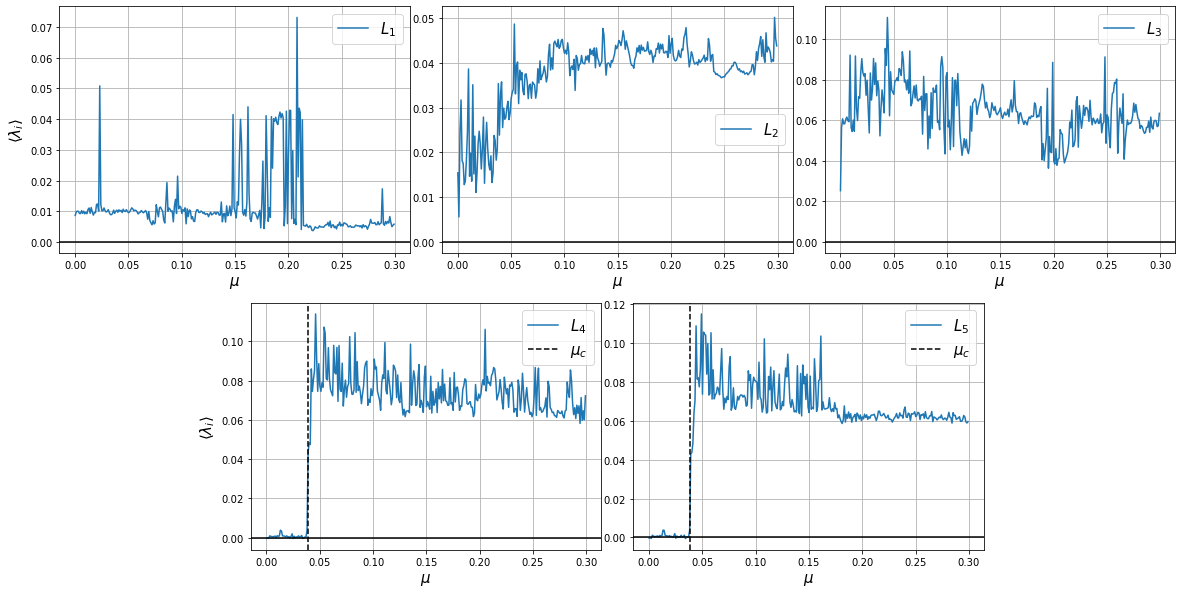

In [70]:

plt.figure(figsize = (20, 10))

ax1 = plt.subplot2grid(shape=(2,6), loc=(0,0), colspan=2)

ax1.plot(mu_arr, lyap[:, 0], label = r'$L_1$')
ax1.axhline(0, c = 'black')

ax1.set_xlabel(r'$\mu$', fontsize = 15)
ax1.set_ylabel(r'$\langle\lambda_i\rangle$', fontsize = 15)

ax1.grid(visible = True)
ax1.legend(fontsize = 15)


ax2 = plt.subplot2grid((2,6), (0,2), colspan=2)

ax2.plot(mu_arr, lyap[:, 1], label = r'$L_2$')
ax2.axhline(0, c = 'black')

ax2.set_xlabel(r'$\mu$', fontsize = 15)

ax2.grid(visible = True)
ax2.legend(fontsize = 15)


ax3 = plt.subplot2grid((2,6), (0,4), colspan=2)

ax3.plot(mu_arr, lyap[:, 2], label = r'$L_3$')
ax3.axhline(0, c = 'black')

ax3.set_xlabel(r'$\mu$', fontsize = 15)

ax3.grid(visible = True)
ax3.legend(fontsize = 15)


ax4 = plt.subplot2grid((2,6), (1,1), colspan=2)

ax4.plot(mu_arr, lyap[:, 3], label = r'$L_4$')
ax4.axhline(0, c = 'black')
ax4.axvline((1-np.sqrt(23/27))/2, c = 'black', linestyle = 'dashed', label = r'$\mu_{c}$')

ax4.set_xlabel(r'$\mu$', fontsize = 15)
ax4.set_ylabel(r'$\langle\lambda_i\rangle$', fontsize = 15)

ax4.grid(visible = True)
ax4.legend(fontsize = 15)


ax5 = plt.subplot2grid((2,6), (1,3), colspan=2)

ax5.plot(mu_arr, lyap[:, 4], label = r'$L_5$')
ax5.axhline(0, c = 'black')
ax5.axvline((1-np.sqrt(23/27))/2, c = 'black', linestyle = 'dashed', label = r'$\mu_{c}$')

ax5.set_xlabel(r'$\mu$', fontsize = 15)

ax5.grid(visible = True)
ax5.legend(fontsize = 15)

plt.savefig('Mean_lyapunov.pdf', format = 'pdf')



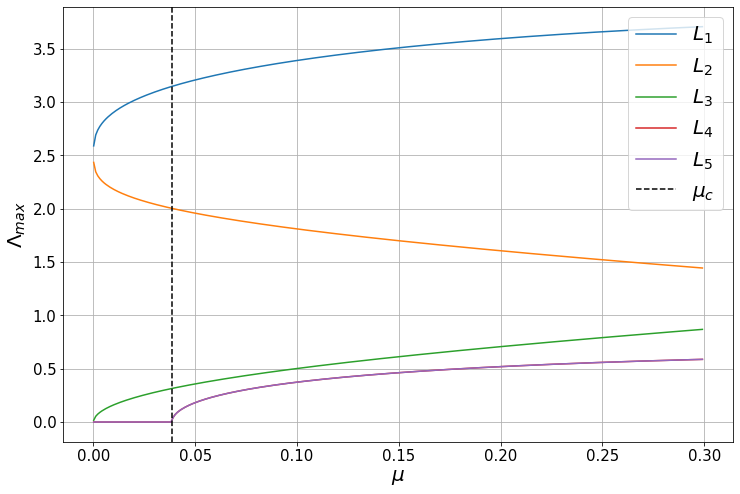

In [71]:
plt.figure(figsize = (12, 8))

for i in range(5):
    plt.plot(mu_arr, lyap_analitico[:, i], label = fr'$L_{1+i}$')

plt.axvline((1-np.sqrt(23/27))/2, c = 'black', linestyle = 'dashed', label = r'$\mu_c$')

plt.xlabel(r'$\mu$', fontsize = 20)
plt.ylabel(r'$\Lambda_{max}$', fontsize = 20)
plt.tick_params(labelsize = 15)

plt.grid(visible = True)

plt.legend(fontsize = 20)

plt.savefig('Analytical_max_lyapunov.pdf', format = 'pdf')


In [12]:
@njit()
def rk4_step_fast(r, v, mu, h):
    # Desempacota os arrays em variáveis escalares (vai direto para o processador)
    rx, ry = r[0], r[1]
    vx, vy = v[0], v[1]
    
    # Único array alocado na memória para servir de entrada na sua função do potencial
    r_temp = np.zeros(2)
    
    # --- PASSO 1 ---
    r_temp[0], r_temp[1] = rx, ry
    ax1 =  2 * vy + Inertial_pot_der(r_temp, mu, 0)
    ay1 = -2 * vx + Inertial_pot_der(r_temp, mu, 1)
    k1_rx, k1_ry = vx, vy
    k1_vx, k1_vy = ax1, ay1
    
    # --- PASSO 2 ---
    r_temp[0], r_temp[1] = rx + 0.5*h*k1_rx, ry + 0.5*h*k1_ry
    ax2 =  2 * (vy + 0.5*h*k1_vy) + Inertial_pot_der(r_temp, mu, 0)
    ay2 = -2 * (vx + 0.5*h*k1_vx) + Inertial_pot_der(r_temp, mu, 1)
    k2_rx, k2_ry = vx + 0.5*h*k1_vx, vy + 0.5*h*k1_vy
    k2_vx, k2_vy = ax2, ay2
    
    # --- PASSO 3 ---
    r_temp[0], r_temp[1] = rx + 0.5*h*k2_rx, ry + 0.5*h*k2_ry
    ax3 =  2 * (vy + 0.5*h*k2_vy) + Inertial_pot_der(r_temp, mu, 0)
    ay3 = -2 * (vx + 0.5*h*k2_vx) + Inertial_pot_der(r_temp, mu, 1)
    k3_rx, k3_ry = vx + 0.5*h*k2_vx, vy + 0.5*h*k2_vy
    k3_vx, k3_vy = ax3, ay3
    
    # --- PASSO 4 ---
    r_temp[0], r_temp[1] = rx + h*k3_rx, ry + h*k3_ry
    ax4 =  2 * (vy + h*k3_vy) + Inertial_pot_der(r_temp, mu, 0)
    ay4 = -2 * (vx + h*k3_vx) + Inertial_pot_der(r_temp, mu, 1)
    k4_rx, k4_ry = vx + h*k3_vx, vy + h*k3_vy
    k4_vx, k4_vy = ax4, ay4
    
    # --- COMBINAÇÃO FINAL ---
    # Só empacotamos de volta no final para devolver os novos r e v
    r_next = np.array([rx + (h/6.0)*(k1_rx + 2*k2_rx + 2*k3_rx + k4_rx),
                       ry + (h/6.0)*(k1_ry + 2*k2_ry + 2*k3_ry + k4_ry)])
    
    v_next = np.array([vx + (h/6.0)*(k1_vx + 2*k2_vx + 2*k3_vx + k4_vx),
                       vy + (h/6.0)*(k1_vy + 2*k2_vy + 2*k3_vy + k4_vy)])
                       
    return r_next, v_next

@njit()
def benettin_mle(mu, r0, v0, T, h, d0=1e-8):
    steps = int(T / h)
    
    # 1. Configurando a órbita Nominal
    r_ref = r0.copy()
    v_ref = v0.copy()
    
    # 2. Configurando a órbita Perturbada
    # Criamos a perturbação no eixo X, o sistema cuidará do resto
    r_pert = r0.copy()
    r_pert[0] += d0
    v_pert = v0.copy()
    
    soma_log = 0.0
    
    for i in range(steps):
        # Avança ambas as órbitas 1 passo no tempo
        r_ref_next, v_ref_next = rk4_step_fast(r_ref, v_ref, mu, h)
        r_pert_next, v_pert_next = rk4_step_fast(r_pert, v_pert, mu, h)
        
        # Calcula o vetor de separação nas 4 coordenadas
        dr = r_pert_next - r_ref_next
        dv = v_pert_next - v_ref_next
        
        # Mede a distância d1 no espaço de fase completo
        d1 = np.sqrt(dr[0]**2 + dr[1]**2 + dv[0]**2 + dv[1]**2)
        
        # Prevenção contra colapso numérico (se as órbitas caírem exatamente no mesmo ponto)
        if d1 == 0:
            d1 = 1e-16
            
        # Acumula a taxa de expansão
        soma_log += np.log(d1 / d0)
        
        # RENORMALIZAÇÃO: Encolhe a distância de volta para d0
        fator = d0 / d1
        r_pert = r_ref_next + dr * fator
        v_pert = v_ref_next + dv * fator
        
        # Atualiza a referência para o próximo loop
        r_ref = r_ref_next
        v_ref = v_ref_next
        
    # O Expoente Máximo de Lyapunov é a média no tempo
    return soma_log / T

@njit(parallel = True)
def Lyapunov_Benettin_Scan(T, h, mu_arr):
    # Matriz para armazenar o MLE dos 5 pontos para cada mu
    Lyapunov_exp = np.zeros((len(mu_arr), 5))
    
    for k in prange(len(mu_arr)):
        mu = mu_arr[k]
        
        # Invoca o seu código corrigido do Newton-Raphson
        pontos_colineares = newton_raphson_lagrange(mu)

        # Nos pontos de Lagrange as partículas iniciam em repouso
        v0 = np.array([0.0, 0.0])

        L_points = np.array([
            [pontos_colineares[0], 0.0],
            [pontos_colineares[1], 0.0],
            [pontos_colineares[2], 0.0],
            [0.5 - mu,  np.sqrt(3.0)/2.0],
            [0.5 - mu, -np.sqrt(3.0)/2.0]
        ])
        
        for i in range(5):
            r0 = L_points[i]
            
            # Aqui calculamos o MLE sem risco nenhum de saturação!
            mle = benettin_mle(mu, r0, v0, T, h)
            
            Lyapunov_exp[k, i] = mle
            
    return Lyapunov_exp

In [31]:
T = 200
h = 1e-3
mu_arr = np.arange(1e-4, 3e-1, 1e-3)

Lyapunov_benettin = Lyapunov_Benettin_Scan(T, h, mu_arr) 

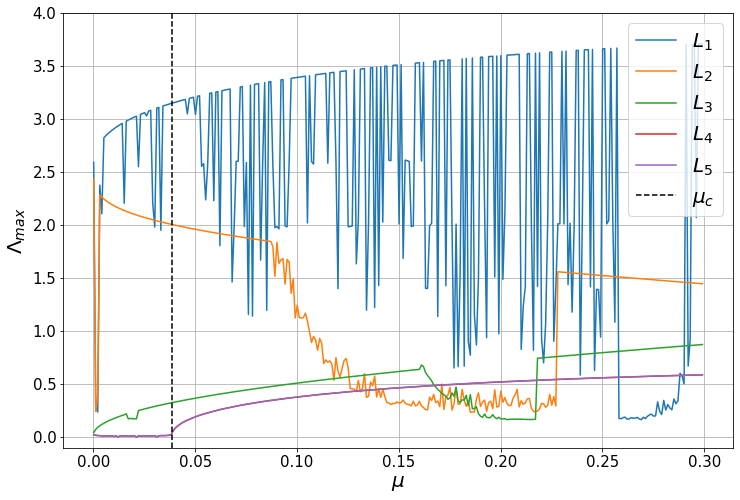

In [33]:
plt.figure(figsize = (12, 8))

for i in range(5):
    plt.plot(mu_arr, Lyapunov_benettin[:, i], label = fr'$L_{1+i}$')

plt.axvline((1-np.sqrt(23/27))/2, c = 'black', linestyle = 'dashed', label = r'$\mu_c$')

plt.xlabel(r'$\mu$', fontsize = 20)
plt.ylabel(r'$\Lambda_{max}$', fontsize = 20)
plt.tick_params(labelsize = 15)

plt.grid(visible = True)

plt.ylim(-0.1, 4)

plt.legend(fontsize = 20)

plt.savefig('Benettin_lyapunov.pdf', format = 'pdf')

#plt.plot(mu_arr, Lyapunov_benettin[:, 4])